In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
from functions.plot_function import (plot_joint_trajectory,
                                     plot_joints_trajectory,
                                     plot_joint_index,
                                     animate_joint_index)
from functions.load_data import load_data, load_multi_data
from sklearn.decomposition import PCA
import joblib
import os

In [24]:
CASE = 'flat'
FOLDER = 'cot2'
# TRIAL = [0,1,2,3,4]
TRIAL = [99]

MODEL = "hebb"
BASE_PATH = f'C:\\Users\\emper\\Desktop\\ICRA2026\\locomotion_learning_information-theory\\sim2real_plot\\logs'

flat_hebb = load_multi_data("flat", FOLDER, "hebb", TRIAL, BASE_PATH)
flat_ff = load_multi_data("flat", FOLDER, "ff", TRIAL, BASE_PATH)
# # --
# flat_hebb_base = load_multi_data("flat", "base", "hebb", [0,1], BASE_PATH)
# flat_ff_base = load_multi_data("flat", "base", "ff", [0,1], BASE_PATH)



# s15lr_hebb = load_multi_data("s15lr", FOLDER, "hebb", TRIAL, BASE_PATH)
# s15lr_ff = load_multi_data("s15lr", FOLDER, "ff", TRIAL, BASE_PATH)

s20l_hebb = load_multi_data("s20l", FOLDER, "hebb", TRIAL, BASE_PATH)
s20l_ff = load_multi_data("s20l", FOLDER, "ff", TRIAL, BASE_PATH)

In [19]:
flat_hebb[0].keys()

dict_keys(['pos', 'pos_deg', 'act', 'act_lowpass', 'cmd_deg', 'vel', 'current', 'voltage', 'dt'])

### Step 1 - analyze one joint


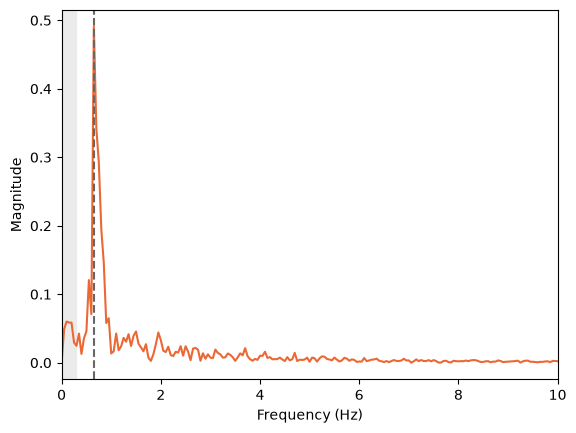

Joint 0 main frequency: 0.65 Hz (magnitude 0.491)
Frequency resolution: 0.050 Hz


In [15]:
FS = 50.0     # control rate (Hz)
FMIN = 0.3    # peak search floor - below this is body drift, not gait

def analyze_frequency(signal, fs=FS, fmin=FMIN):
    """FFT of ONE joint signal.

    Returns (freqs, magnitude, main_freq, main_magnitude).

    Two things are kept out of the peak search:
      bin 0 (DC)     - a joint with a non-zero offset would peak at 0 Hz.
      below `fmin`   - on long recordings the body slowly drifts and that trend
                       outweighs the gait cycle. Without the floor, all 19 joints
                       of base/rough/hebb-0 peak at 0.05 Hz, the lowest bin a 20 s
                       window has: "no periodicity", reported as a frequency.
    """
    x = np.asarray(signal, dtype=float)
    x = x - x.mean()
    n = len(x)
    freqs = np.fft.rfftfreq(n, 1 / fs)      # one-sided, no manual halving
    mag = np.abs(np.fft.rfft(x)) * 2 / n    # scaled to amplitude units
    lo = max(1, int(np.searchsorted(freqs, fmin)))
    k = np.argmax(mag[lo:]) + lo
    return freqs, mag, freqs[k], mag[k]


# --- try it on a single joint
data = np.array(flat_hebb[0]['pos'])   # (T, 19)
freqs, mag, main_freq, main_mag = analyze_frequency(data[:, 0])

plt.plot(freqs, mag, color="#eb6834")
plt.axvline(main_freq, color="0.4", ls="dashed")
plt.axvspan(0, FMIN, color="0.92", zorder=0)   # excluded drift band
plt.xlim(0, 10)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

print(f"Joint 0 main frequency: {main_freq:.2f} Hz (magnitude {main_mag:.3f})")
print(f"Frequency resolution: {FS / len(data):.3f} Hz")


### Step 2 - apply to every joint


In [16]:
def plot_all_joint_frequency(data, fs=FS, fmax=10, title_name="",
                             save_path=None, show=True, fmin=FMIN):
    """FFT of every joint on a 5x4 grid, each panel labelled with its main
    frequency. Returns the per-joint main frequencies."""
    D = np.array(data)
    n_joints = D.shape[1]
    COLOR = "#eb6834"

    fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(22, 14))
    fig.suptitle(title_name, fontsize=20, fontweight="bold", y=0.94)
    axes = axes.flatten()
    plt.subplots_adjust(hspace=0.45)

    main_freqs = []
    for j in range(n_joints):
        f, mag, f0, m0 = analyze_frequency(D[:, j], fs, fmin)
        main_freqs.append(f0)

        ax = axes[j]
        ax.plot(f, mag, color=COLOR, lw=1.3)
        ax.axvspan(0, fmin, color="0.92", zorder=0)  # excluded drift band
        ax.axvline(f0, color="0.4", ls="dashed", lw=1.0)
        ax.set_xlim(0, fmax)
        ax.set_title(f"Joint {j}", fontsize=12, pad=2, alpha=0.7)
        ax.text(0.96, 0.90, f"{f0:.2f} Hz", transform=ax.transAxes,
                ha="right", va="top", fontsize=11, color="0.25",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8"))
        ax.spines[["top", "right"]].set_visible(False)

    for ax in axes[:n_joints][-4:]:
        ax.set_xlabel("Frequency (Hz)")

    # summary of the whole system in the spare 20th panel
    main_freqs = np.array(main_freqs)
    axes[-1].axis("off")
    axes[-1].text(0.5, 0.5,
                  f"System main frequency\n{main_freqs.mean():.2f} Hz\n"
                  f"(std {main_freqs.std():.2f}, n={n_joints} joints)",
                  ha="center", va="center", fontsize=14, fontweight="bold")

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="white")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return main_freqs


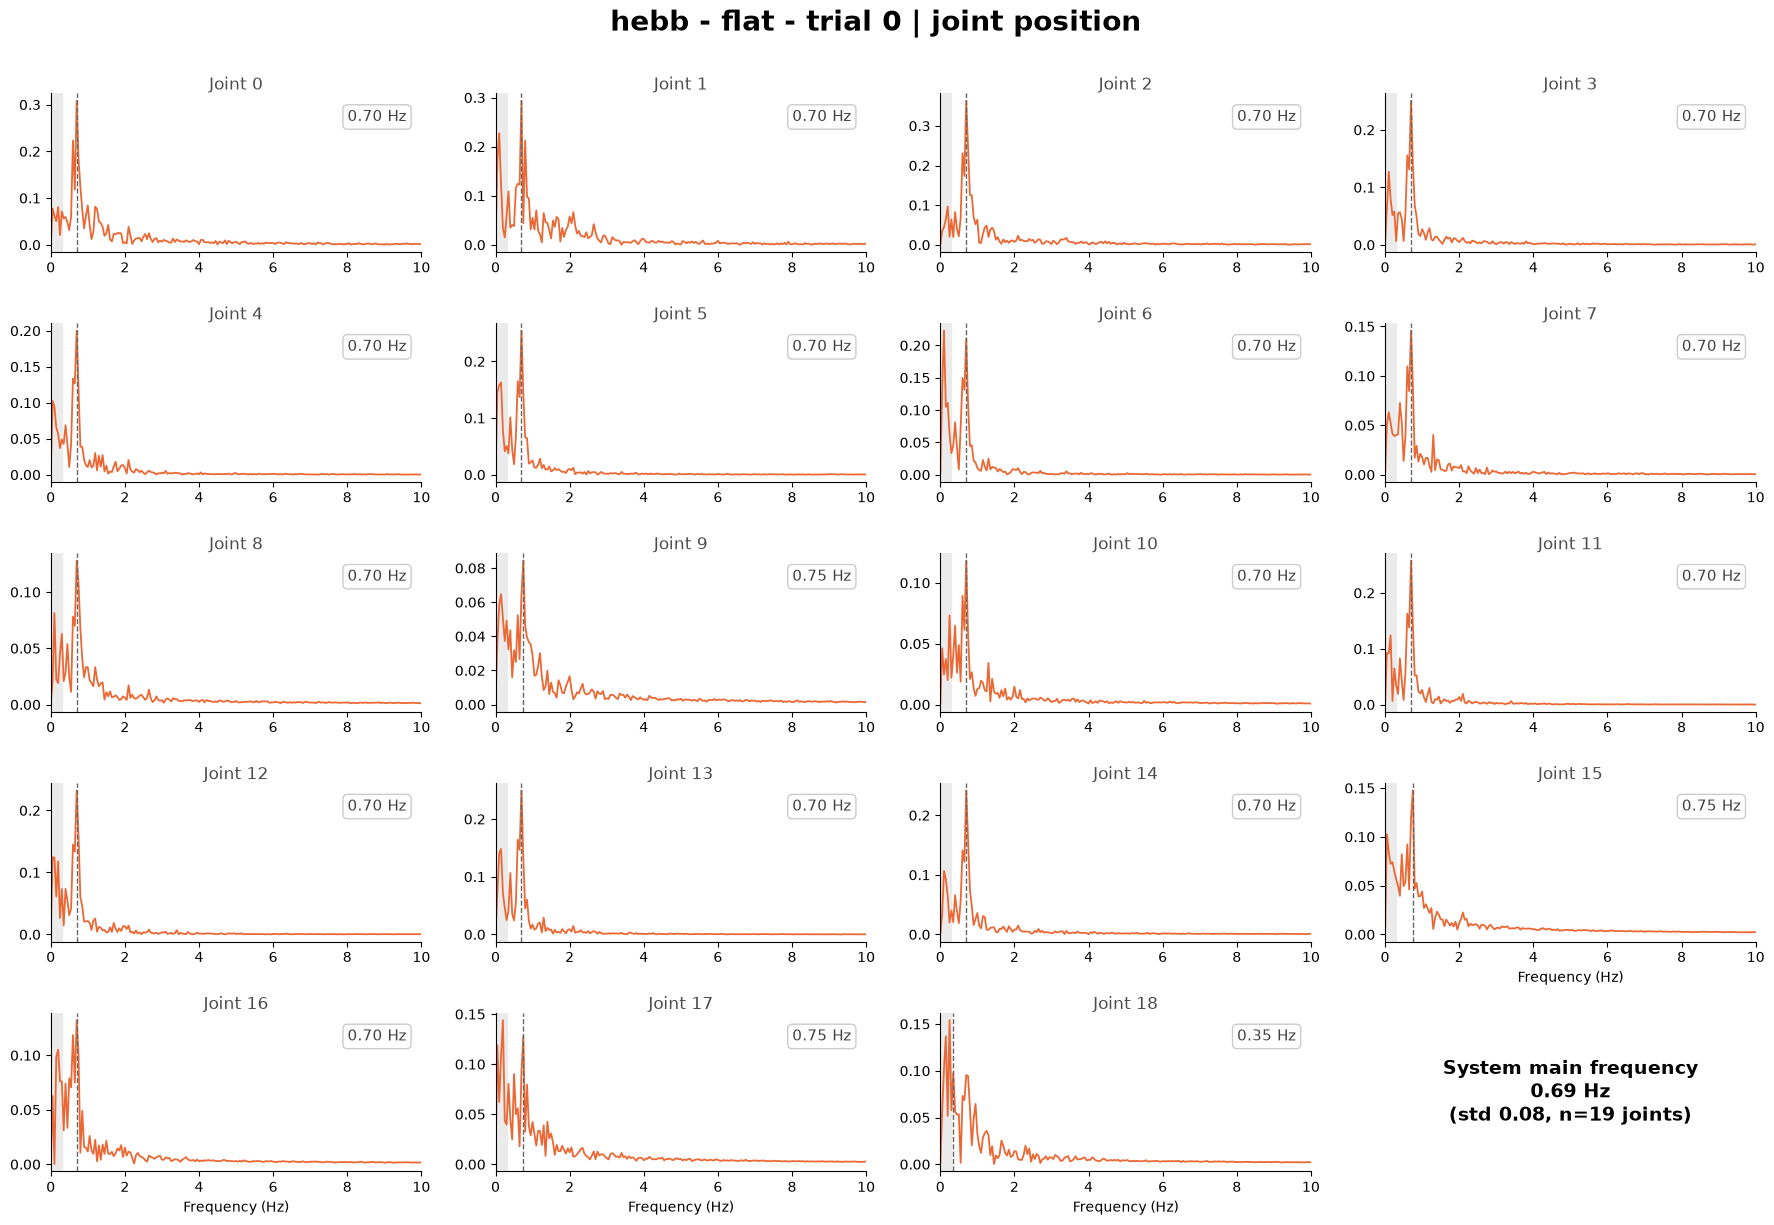

Per-joint main frequency (Hz):
  joint  0: 0.70
  joint  1: 0.70
  joint  2: 0.70
  joint  3: 0.70
  joint  4: 0.70
  joint  5: 0.70
  joint  6: 0.70
  joint  7: 0.70
  joint  8: 0.70
  joint  9: 0.75
  joint 10: 0.70
  joint 11: 0.70
  joint 12: 0.70
  joint 13: 0.70
  joint 14: 0.70
  joint 15: 0.75
  joint 16: 0.70
  joint 17: 0.75
  joint 18: 0.35

System main frequency = 0.689 Hz (std 0.082)


In [23]:
main_freqs = plot_all_joint_frequency(
    np.array(s20l_hebb[0]['pos']),
    fmax=10,
    title_name="hebb - flat - trial 0 | joint position",
)

print("Per-joint main frequency (Hz):")
for j, f0 in enumerate(main_freqs):
    print(f"  joint {j:2d}: {f0:.2f}")

print(f"\nSystem main frequency = {main_freqs.mean():.3f} Hz "
      f"(std {main_freqs.std():.3f})")


### Step 3 - one reusable pipeline per log folder


In [ ]:
import glob, re
import pandas as pd

# ---- palette: categorical slots 1 & 2, validated (CVD dE 24.7, all checks pass)
C_HEBB, C_FF = "#2a78d6", "#eb6834"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
MODELS = [("hebb", C_HEBB, "Hebbian"), ("ff", C_FF, "Feedforward")]


def discover(folder, case, model, trials=None):
    """Trial ids actually present on disk, as (trial, path). Files with no
    -N suffix (e.g. base/slope_down) are treated as trial 0."""
    pat = os.path.join(BASE_PATH, folder, case, f"{model}-pos_act_model0_buffer*.json")
    out = []
    for path in glob.glob(pat):
        m = re.search(r"buffer-(\d+)\.json$", path)
        t = int(m.group(1)) if m else 0
        if trials is None or t in trials:
            out.append((t, path))
    return sorted(out)


def _fmt(m, s, n):
    if pd.isna(m):
        return "-"
    return f"{m:.2f} ± {s:.2f}" if n > 1 else f"{m:.2f}"


def run_folder(folder, trials=None, fmax=10, fmin=FMIN):
    """FFT every trial in one log folder, then write the grids, the summary
    CSVs, the table figure and the bar chart into figures/freq/<folder>/."""
    out_dir = os.path.join(os.path.dirname(BASE_PATH), "figures", "freq", folder)
    os.makedirs(out_dir, exist_ok=True)

    root = os.path.join(BASE_PATH, folder)
    cases = sorted(d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d)))

    records = []
    for case in cases:
        for model, _, _ in MODELS:
            for trial, path in discover(folder, case, model, trials):
                with open(path, "r") as f:
                    pos = np.array(json.load(f)["pos"])
                mf = plot_all_joint_frequency(
                    pos, fmax=fmax, fmin=fmin,
                    title_name=f"{folder} | {case} - {model} - trial {trial}",
                    save_path=os.path.join(out_dir, f"{case}-{model}-{trial}.png"),
                    show=False)
                records.append({"case": case, "model": model, "trial": trial,
                                "main_freq": mf.mean(), "joint_std": mf.std()})

    trial_df = pd.DataFrame(records)
    trial_df.to_csv(os.path.join(out_dir, "freq_per_trial.csv"), index=False)

    summary = (trial_df.groupby(["case", "model"])["main_freq"]
                       .agg(n="count", mean_Hz="mean", std_Hz="std")
                       .round(3))
    summary.to_csv(os.path.join(out_dir, "freq_summary.csv"))
    case_order = sorted(trial_df["case"].unique())

    # ------------------------------ table figure ------------------------------
    rows = []
    for case in case_order:
        vals = {}
        for model, _, _ in MODELS:
            key = (case, model)
            if key in summary.index:
                r = summary.loc[key]
                vals[model] = (r["mean_Hz"], r["std_Hz"], int(r["n"]))
            else:
                vals[model] = (np.nan, np.nan, 0)
        h, f = vals["hebb"], vals["ff"]
        ratio = f"{f[0] / h[0]:.2f}×" if not (pd.isna(h[0]) or pd.isna(f[0])) else "-"
        rows.append([case, f"{h[2]} / {f[2]}", _fmt(*h), _fmt(*f), ratio])
    cols = ["Case", "n (hebb/ff)", "Hebbian (Hz)", "Feedforward (Hz)", "ff / hebb"]

    fig, ax = plt.subplots(figsize=(10, 0.52 * len(rows) + 1.5))
    fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE); ax.axis("off")
    tbl = ax.table(cellText=rows, colLabels=cols, cellLoc="center", loc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 1.7)
    for (r, c), cell in tbl.get_celld().items():
        cell.visible_edges = "horizontal"
        cell.set_edgecolor(BASELINE if r == 0 else GRID)
        cell.set_linewidth(1.1 if r == 0 else 0.6)
        if r == 0:
            cell.set_text_props(color=INK, fontweight="bold")
        else:
            cell.set_text_props(color={2: C_HEBB, 3: C_FF}.get(c, INK2))
    ax.set_title(f"'{folder}' - gait main frequency by case and model "
                 f"(mean ± std over trials)",
                 fontsize=12, fontweight="bold", color=INK, pad=14)
    fig.savefig(os.path.join(out_dir, "freq_summary_table.png"),
                dpi=200, bbox_inches="tight", facecolor=SURFACE)
    plt.show()

    # ------------------------------- bar chart --------------------------------
    x = np.arange(len(case_order))
    width = 0.30
    fig, ax = plt.subplots(figsize=(max(7, 1.5 * len(case_order) + 2), 5.2))
    fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
    top_of_chart = 0.0

    for i, (model, color, label) in enumerate(MODELS):
        sub = (summary.xs(model, level="model") if model in
               summary.index.get_level_values("model") else pd.DataFrame())
        sub = sub.reindex(case_order)
        off = (i - 0.5) * (width + 0.03)
        ax.bar(x + off, sub["mean_Hz"], width, color=color, label=label, zorder=2)
        ax.errorbar(x + off, sub["mean_Hz"], yerr=sub["std_Hz"].fillna(0), fmt="none",
                    ecolor=INK2, elinewidth=1.1, capsize=4, capthick=1.1, zorder=4)
        pts = trial_df[trial_df.model == model]
        for k, case in enumerate(case_order):
            v = pts[pts.case == case]["main_freq"].values
            if len(v) == 0:
                continue
            ax.scatter(np.full(len(v), x[k] + off), v, s=22, zorder=5,
                       facecolor=SURFACE, edgecolor=INK2, linewidth=1.1)
            m = sub["mean_Hz"].get(case, np.nan)
            if pd.isna(m):
                continue
            top = max(m + (0 if pd.isna(sub["std_Hz"].get(case)) else sub["std_Hz"][case]),
                      v.max())
            top_of_chart = max(top_of_chart, top)
            ax.text(x[k] + off, top + 0.04, f"{m:.2f}", ha="center", va="bottom",
                    fontsize=9.5, color=INK)

    ax.set_xticks(x)
    ax.set_xticklabels(case_order, color=INK2, fontsize=10,
                       rotation=25 if len(case_order) > 4 else 0,
                       ha="right" if len(case_order) > 4 else "center")
    ax.set_ylabel("Main frequency (Hz)", color=INK2, fontsize=11)
    ax.set_ylim(0, top_of_chart * 1.18)
    ax.yaxis.grid(True, color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines["left"].set_color(BASELINE); ax.spines["bottom"].set_color(BASELINE)
    ax.tick_params(colors=MUTED, length=0)
    ax.legend(frameon=False, ncols=2, loc="lower right", bbox_to_anchor=(1, 1.01),
              labelcolor=INK2, fontsize=10.5)
    ax.set_title(f"'{folder}' - gait frequency by case and controller",
                 fontsize=13, fontweight="bold", color=INK, pad=34, loc="left")
    fig.savefig(os.path.join(out_dir, "freq_bar.png"),
                dpi=200, bbox_inches="tight", facecolor=SURFACE)
    plt.show()

    print(summary)
    print(f"\n{folder}: {len(trial_df)} trials over {len(case_order)} cases "
          f"-> {out_dir}")
    return trial_df, summary


### Step 4 - run each folder separately


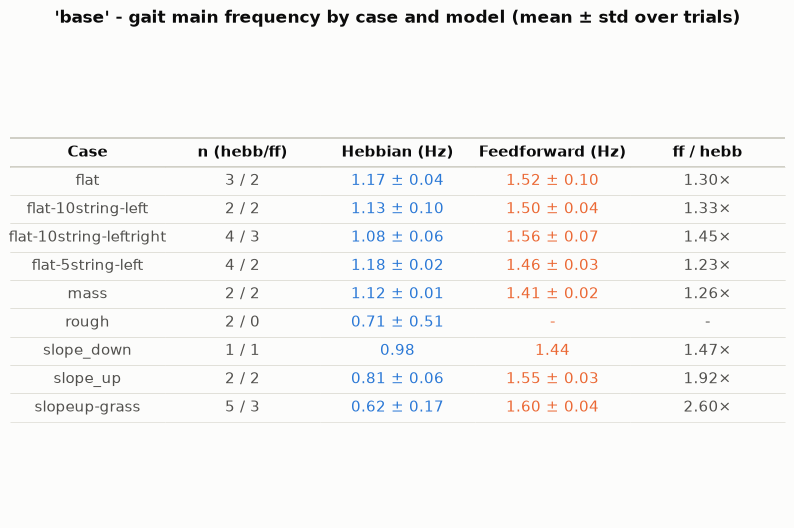

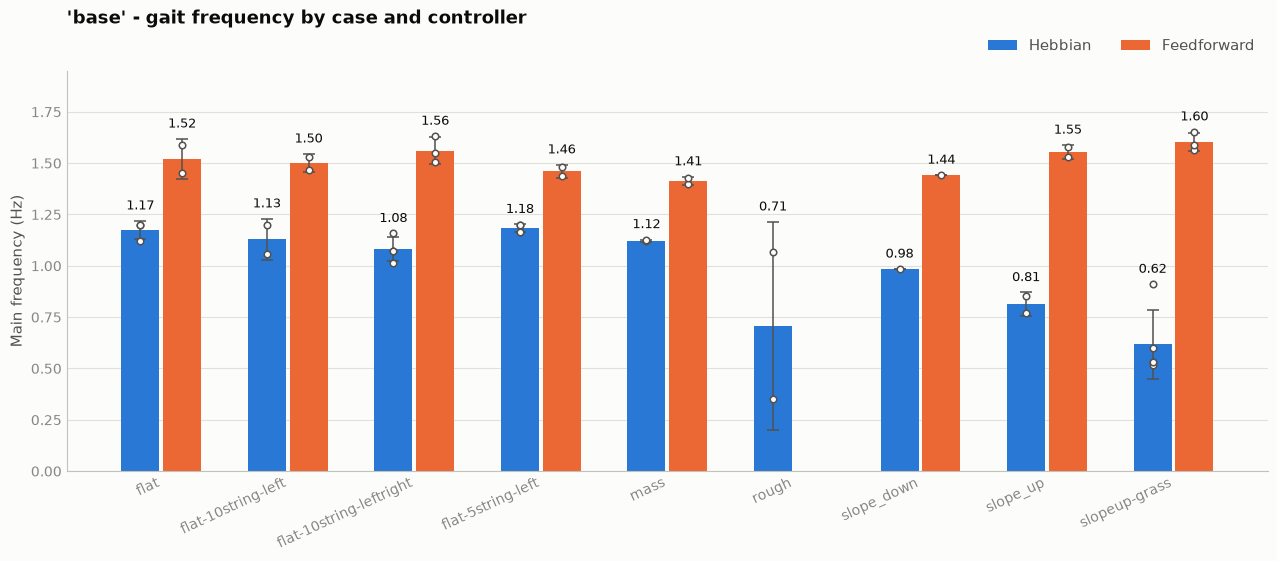

                               n  mean_Hz  std_Hz
case                    model                    
flat                    ff     2    1.521   0.097
                        hebb   3    1.174   0.045
flat-10string-left      ff     2    1.500   0.045
                        hebb   2    1.129   0.100
flat-10string-leftright ff     3    1.561   0.065
                        hebb   4    1.080   0.059
flat-5string-left       ff     2    1.461   0.031
                        hebb   4    1.183   0.019
mass                    ff     2    1.414   0.020
                        hebb   2    1.122   0.006
rough                   hebb   2    0.708   0.506
slope_down              ff     1    1.442     NaN
                        hebb   1    0.984     NaN
slope_up                ff     2    1.555   0.033
                        hebb   2    0.812   0.058
slopeup-grass           ff     3    1.602   0.045
                        hebb   5    0.617   0.167

base: 42 trials over 9 cases -> C:\Users\emper\De

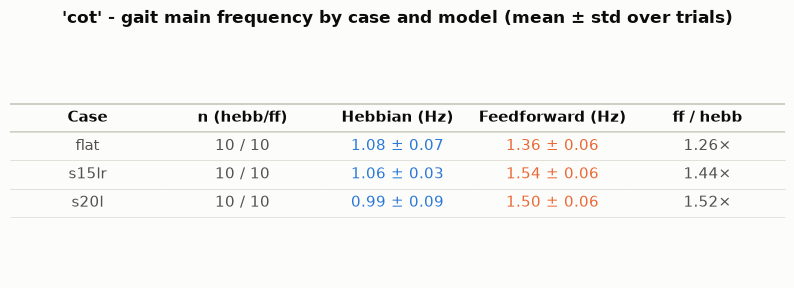

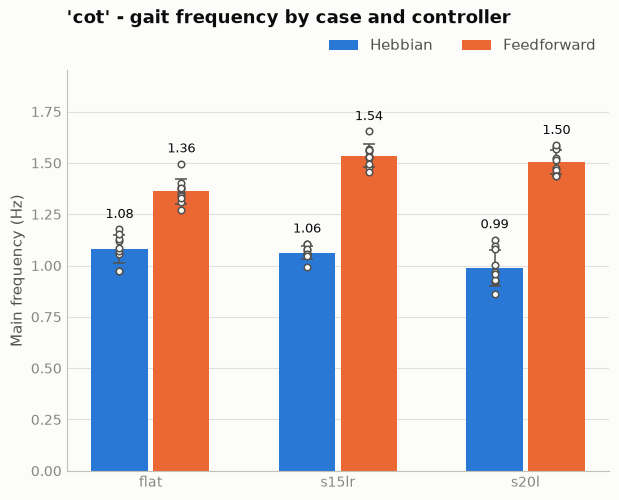

              n  mean_Hz  std_Hz
case  model                     
flat  ff     10    1.363   0.061
      hebb   10    1.079   0.068
s15lr ff     10    1.536   0.055
      hebb   10    1.063   0.033
s20l  ff     10    1.503   0.059
      hebb   10    0.986   0.088

cot: 60 trials over 3 cases -> C:\Users\emper\Desktop\ICRA2026\locomotion_learning_information-theory\sim2real_plot\figures\freq\cot


In [ ]:
# base: every trial that exists (trial ids there are sparse and non-contiguous)
base_trials, base_summary = run_folder("base")

# cot: trials 0-9 only (99 and 100 are excluded)
cot_trials, cot_summary = run_folder("cot", trials=range(10))
